In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from PcmPy.sim import make_signal


# generate true Us

In [2]:
n_subs = 24
n_parcel = 32
n_voxels  = 100
n_tasks = 8

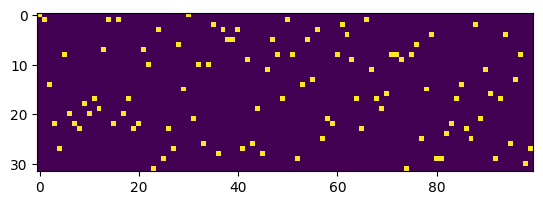

In [3]:
U_true = sim.generate_Us(s= n_subs, k = n_parcel, p = n_voxels, type= 'hard')
plt.imshow(U_true[2])

# Generate test data (random Vs)

In [4]:
V_test = Vs = np.random.normal(0, 1, (n_tasks, n_parcel))
y_test = V_test @ U_true

In [5]:
def evaluate_U_MSE(D,Vs,ytest,vtest):
    for i, row in D.iterrows():
        print(i)
        task_subset_indices = row['combination']
        V_subset = Vs[task_subset_indices, :]
        
        # Subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)
        
        # Generate the data Y from U_true and V_subset
        y_subset = V_subset @ U_true

        # Estimate U_hat using OLS
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
    
        # MSE between U_true and U_hat_ols
        D.at[i, 'OLS_MSE'] = sim.U_MSE(U_true, U_hat_ols)

        # make into tensores
        ytest = pt.tensor(ytest)
        vtest = pt.tensor(vtest)
        U_hat_ols = pt.tensor(U_hat_ols)
        
        # calculate cosine error between ytest reconstrcuted and original
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().numpy()


        D.at[i, 'cos_ols'] = cos_ols

    return D



In [13]:
offsets = np.logspace(-10, 10, num=50)

# Custom Vs

In [14]:
def custom_G_2(n_tasks=16, n_groups=4, group_size=4, target_corr=0.4, 
             variance_factors=[1.0, 0.75, 0.5, 0.25], random_corr_strength=0.1):
    G = np.zeros((n_tasks, n_tasks))
    task_index = 0
    variances_per_task = []

    for group in range(n_groups):
        # Append variance factors for each task in the group
        variances_per_task.extend(variance_factors)

        # Compute covariances within the group based on desired correlation
        covariances = target_corr * np.outer(variance_factors, variance_factors)
        np.fill_diagonal(covariances, variance_factors)

        # Place the block into G
        start, end = task_index, task_index + group_size
        G[start:end, start:end] = covariances

        task_index += group_size

    # Convert variances_per_task to a NumPy array
    variances_per_task = np.array(variances_per_task)
    sqrt_variances = np.sqrt(variances_per_task)
    variance_outer = np.outer(sqrt_variances, sqrt_variances)

    # Assign each task to a group
    task_groups = np.repeat(np.arange(n_groups), group_size)

    # Create a mask for off-block-diagonal elements
    M = task_groups[:, None] != task_groups[None, :]

    # Generate symmetric random correlations
    R = np.random.uniform(-1, 1, size=(n_tasks, n_tasks))
    R = (R + R.T) / 2
    R *= random_corr_strength  # Scale by desired strength

    # Compute random covariances
    random_covariances = R * variance_outer

    # Assign random covariances to off-block-diagonal elements
    G[M] = random_covariances[M]

    return G


In [15]:
def log_min_corr(D):
    offsets = D['offset'].unique()
    correlation_matrix = np.zeros((len(offsets) *2, len(offsets) *2))

    # Loop through all combinations of offsets
    for i, offset_1 in enumerate(offsets):
        for j, offset_2 in enumerate(offsets):
            # Subset for log_det and min_est with offset_1
            subset_1 = D[D['offset'] == offset_1]
            log_det_values_1 = subset_1['log_det'].values
            min_est_values_1 = subset_1['min_est'].values

            # Subset for log_det and min_est with offset_2
            subset_2 = D[D['offset'] == offset_2]
            log_det_values_2 = subset_2['log_det'].values
            min_est_values_2 = subset_2['min_est'].values

            # Calculate correlation between log_det from offset_1 and log_det from offset_2
            log_det_corr = np.corrcoef(log_det_values_1, log_det_values_2)[0, 1]

            # Calculate correlation between min_est from offset_1 and min_est from offset_2
            min_est_corr = np.corrcoef(min_est_values_1, min_est_values_2)[0, 1]

            # Calculate correlation between log_det from offset_1 and min_est from offset_2
            log_det_min_est_corr = np.corrcoef(log_det_values_1, min_est_values_2)[0, 1]

            # Fill in the 20x20 correlation matrix
            correlation_matrix[i, j] = log_det_corr                      # log_det vs log_det
            correlation_matrix[i + len(offsets), j + len(offsets)] = min_est_corr            # min_est vs min_est
            correlation_matrix[i, j + len(offsets)] = log_det_min_est_corr         # log_det vs min_est
            correlation_matrix[i + len(offsets), j] = log_det_min_est_corr         # min_est vs log_det (same value)

    # labels
    log_det_labels = [f'log_det_reg_{offset:.1e}' for offset in offsets]  # e.g., log_det_reg_1e-06
    min_est_labels = [f'min_est_reg_{offset:.1e}' for offset in offsets]  # e.g., min_est_reg_1e-06
    x_labels = log_det_labels + min_est_labels
    y_labels = log_det_labels + min_est_labels

    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, linecolor='gray',
                xticklabels=x_labels, yticklabels=y_labels)
    plt.xticks(rotation=90) 

    name = [x for x in globals() if globals()[x] is D][0]
    #save the figure
    plt.savefig(f'log_min_corr_{name}.png')
    plt.show()

    



In [20]:
def metric_ols_corr(D):
    offsets = D['offset'].unique()
    log_det_corrs = []
    max_var_corrs = []
    min_est_corrs = []

    for offset in offsets:
        subset = D[D['offset'] == offset]
        
        log_det_corr = np.corrcoef(subset['log_det'], subset['OLS_MSE'])[0, 1]
        log_det_corrs.append(log_det_corr)
        
        max_var_corr = np.corrcoef(subset['max_var'], subset['OLS_MSE'])[0, 1]
        max_var_corrs.append(max_var_corr)

        min_est_corr = np.corrcoef(subset['min_est'], subset['OLS_MSE'])[0, 1]
        min_est_corrs.append(min_est_corr)


    plt.plot(offsets, log_det_corrs, label='log_det vs OLS_MSE', marker='x',markersize=1)
    plt.plot(offsets, max_var_corrs, label='max_var vs OLS_MSE', marker='o',markersize=1)
    plt.plot(offsets, min_est_corrs, label='min_est vs OLS_MSE', marker='s',markersize=1)  

    plt.xscale('log')  
    plt.xlabel('Regularization Factor (Offset)')
    plt.ylabel('Correlation with OLS_MSE')
    plt.title('Correlation of log_det and max_var with OLS_MSE')
    plt.legend()
    #save the figure and get the name of the dataframe
    name = [x for x in globals() if globals()[x] is D][0]
    #save the figure
    plt.savefig(f'OLS_corr_{name}.png')
    plt.show()


def metric_HBP_corr(D):
    offsets = D['offset'].unique()
    log_det_corrs = []
    max_var_corrs = []
    min_est_corrs = []

    for offset in offsets:
        subset = D[D['offset'] == offset]
        
        log_det_corr = np.corrcoef(subset['log_det'], subset['cos_HBP'])[0, 1]
        log_det_corrs.append(log_det_corr)
        
        max_var_corr = np.corrcoef(subset['max_var'], subset['cos_HBP'])[0, 1]
        max_var_corrs.append(max_var_corr)

        min_est_corr = np.corrcoef(subset['min_est'], subset['cos_HBP'])[0, 1]
        min_est_corrs.append(min_est_corr)


    plt.plot(offsets, log_det_corrs, label='log_det vs cos_HBP', marker='x')
    plt.plot(offsets, max_var_corrs, label='max_var vs cos_HBP', marker='o')
    plt.plot(offsets, min_est_corrs, label='min_est vs cos_HBP', marker='s')

    plt.xscale('log')  
    plt.xlabel('Regularization Factor (Offset)')
    plt.ylabel('Correlation with cos_HBP')
    plt.title('Correlation of log_det and max_var with cos_HBP')
    plt.legend()

    # save the figure and get the name of the dataframe
    name = [x for x in globals() if globals()[x] is D][0]
    #save the figure
    plt.savefig(f'HBP_corr_{name}.png')
    plt.show()

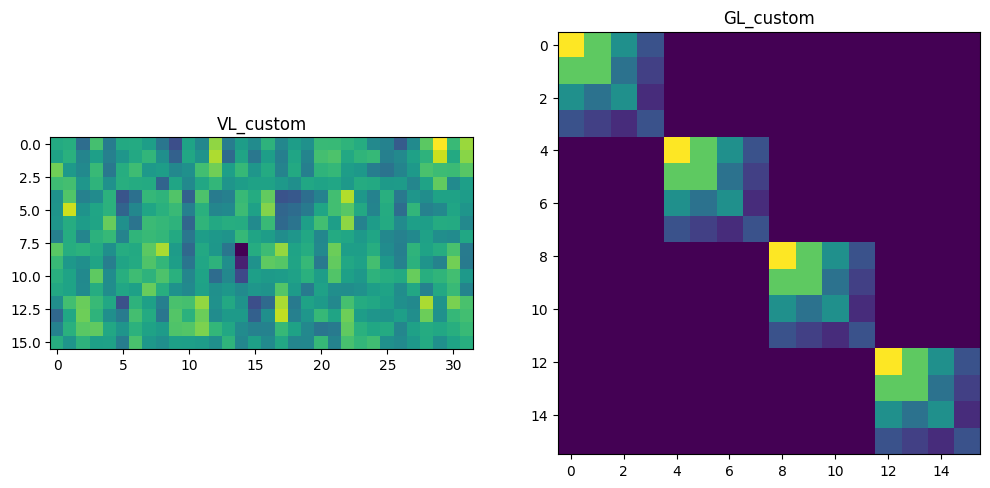

In [17]:
GL_custom = custom_G_2(n_tasks=16, n_groups=4, group_size=4, target_corr=1, variance_factors=[1.0, 0.75, 0.5, 0.25], random_corr_strength=0)
VL_custom = make_signal(G = GL_custom,n_channel=n_parcel,make_exact= True)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_custom)
ax[0].set_title('VL_custom')

ax[1].imshow(GL_custom)
ax[1].set_title('GL_custom')

plt.show()

In [18]:
D_custom = ut.build_combinations(GL_custom, strategy='random',offs=offsets,n_iter=100,n_tasks=8,seed=5)
D_custom = evaluate_U_MSE(D_custom, VL_custom, y_test, V_test)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37


C:\Users\barafat\AppData\Local\Temp\ipykernel_8172\798800627.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
C:\Users\barafat\AppData\Local\Temp\ipykernel_8172\798800627.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
30

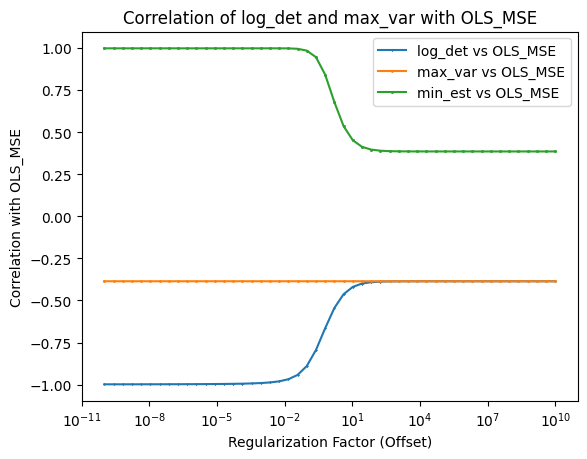

In [21]:
# log_min_corr(D_custom)
metric_ols_corr(D_custom)


# custom with lower covariance in the groups

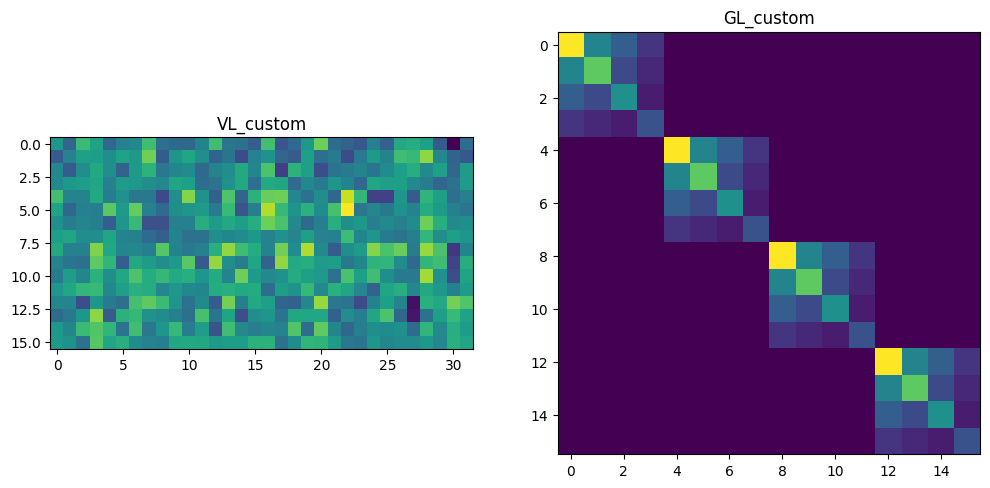

In [12]:
GL_custom_06 = custom_G_2(n_tasks=16, n_groups=4, group_size=4, target_corr=0.6, variance_factors=[1.0, 0.75, 0.5, 0.25], random_corr_strength=0)
VL_custom_06 = make_signal(G = GL_custom_06,n_channel=n_parcel,make_exact= True)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_custom_06)
ax[0].set_title('VL_custom')

ax[1].imshow(GL_custom_06)
ax[1].set_title('GL_custom')

plt.show()

In [13]:
D_custom_06 = ut.build_combinations(GL_custom_06, strategy='random',n_iter=1000,n_tasks=8,seed=5)
D_custom_06 = evaluate_U_MSE(D_custom_06, VL_custom_06, y_test, V_test)

C:\Users\barafat\AppData\Local\Temp\ipykernel_9452\238915427.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
C:\Users\barafat\AppData\Local\Temp\ipykernel_9452\238915427.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


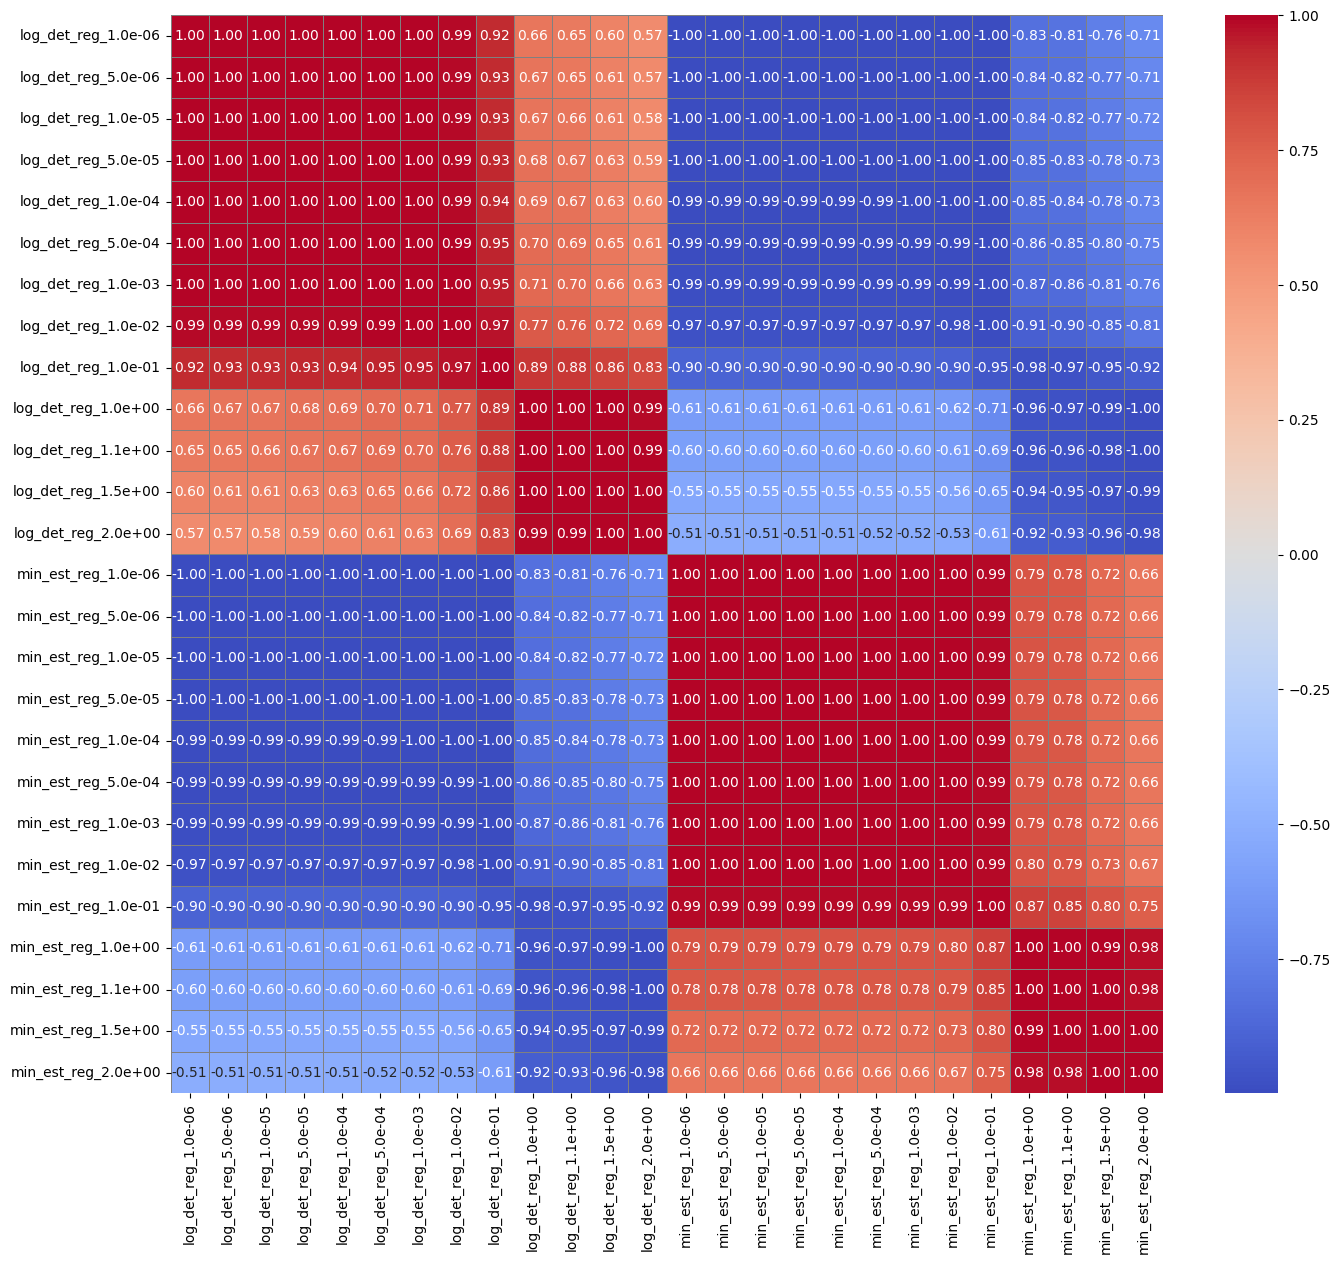

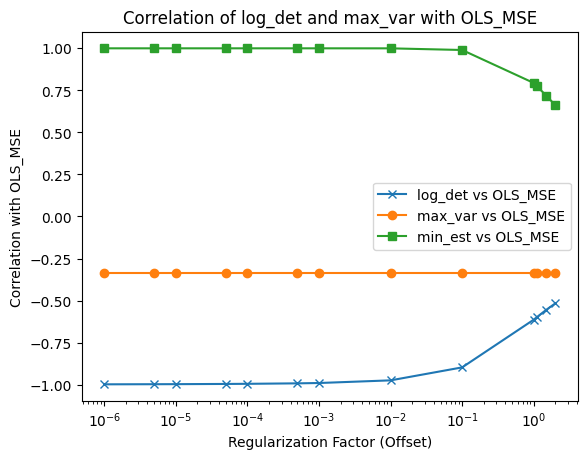

In [14]:
log_min_corr(D_custom_06)
metric_ols_corr(D_custom_06)


# add random covarainces in the off group diagonal

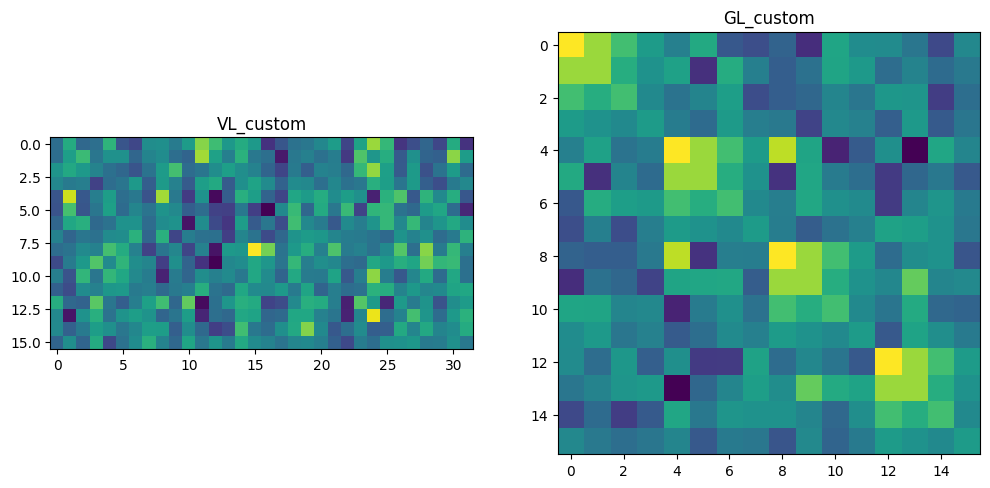

In [15]:
GL_custom_off = custom_G_2(n_tasks=16, n_groups=4, group_size=4, target_corr=1, variance_factors=[1.0, 0.75, 0.5, 0.25], random_corr_strength=0.99)
VL_custom_off = make_signal(G = GL_custom_off,n_channel=n_parcel,make_exact= True)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_custom_off)
ax[0].set_title('VL_custom')

ax[1].imshow(GL_custom_off)
ax[1].set_title('GL_custom')

plt.show()



In [16]:
D_custom_off = ut.build_combinations(GL_custom_off, strategy='random',n_iter=1000,n_tasks=8,seed=5)
D_custom_off = evaluate_U_MSE(D_custom_off, VL_custom_off, y_test, V_test)

C:\Users\barafat\AppData\Local\Temp\ipykernel_9452\238915427.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
C:\Users\barafat\AppData\Local\Temp\ipykernel_9452\238915427.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


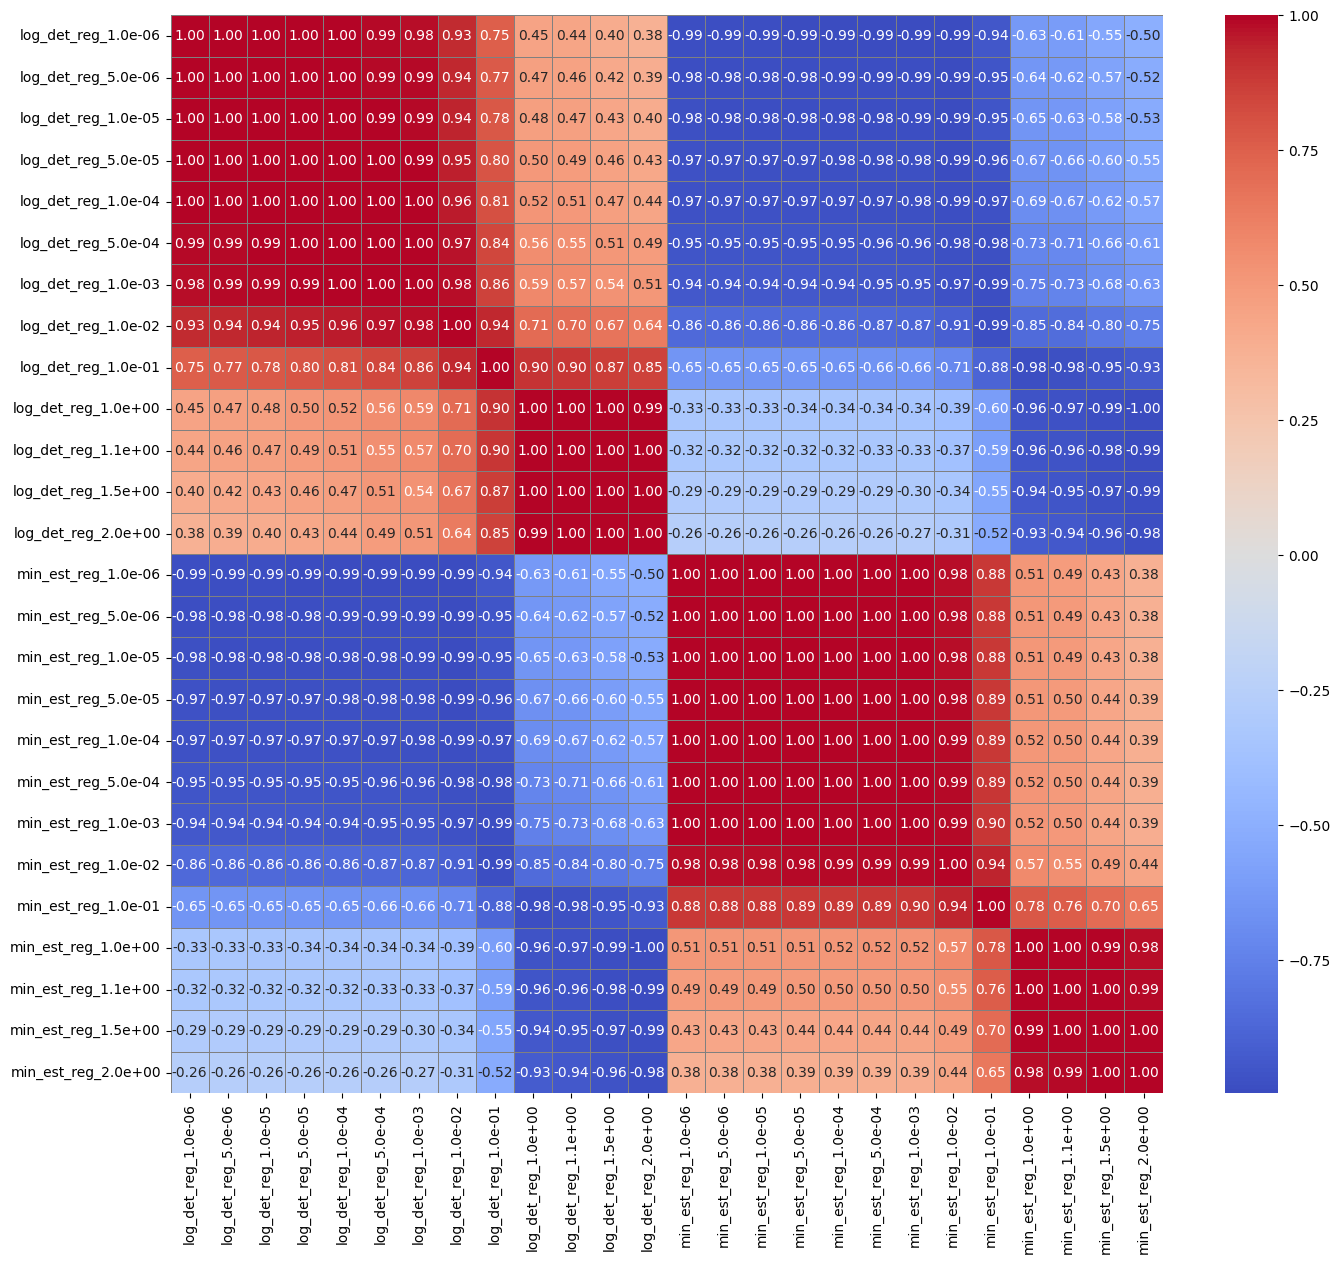

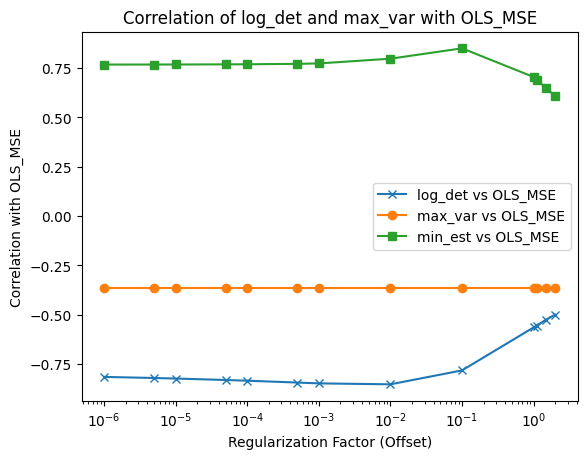

In [17]:
log_min_corr(D_custom_off)
metric_ols_corr(D_custom_off)


# MDTB covariance, simulated data

<Axes: >

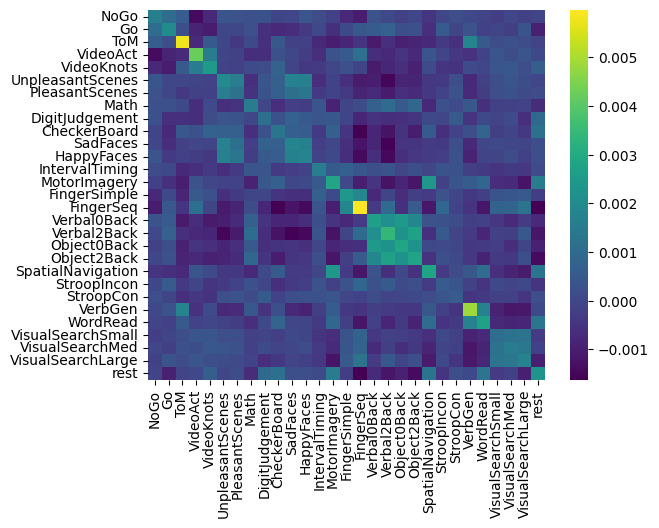

In [18]:
base_dir = 'Y:/data/FunctionalFusion'
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondRun')
task_names = info_mdtb_1.cond_name.values[:29]

cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

task_matrix = data_mdtb_s1
task_matrix[np.isnan(task_matrix)] = 0

Gs_list = []
E_list = []
for i in range(task_matrix.shape[0]):
    Gs,E = pcm.util.est_G_crossval(task_matrix[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

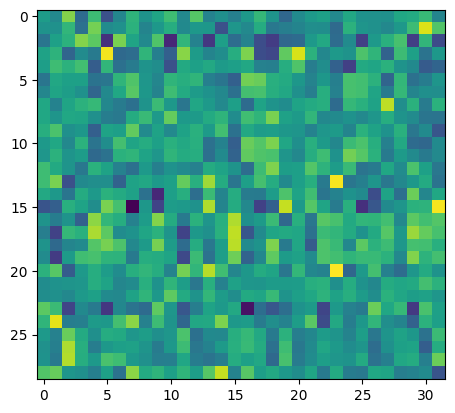

In [19]:
VL_mdtb = make_signal(G = G_individuals_averaged,n_channel=n_parcel,make_exact= True)
plt.imshow(VL_mdtb)

In [26]:
D_MDTB = ut.build_combinations(G_individuals_averaged, strategy='random',n_iter=1000,n_tasks=8,seed=5)
D_MDTB = evaluate_U_MSE(D_MDTB, VL_mdtb, y_test, V_test)


C:\Users\barafat\AppData\Local\Temp\ipykernel_9452\238915427.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
C:\Users\barafat\AppData\Local\Temp\ipykernel_9452\238915427.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


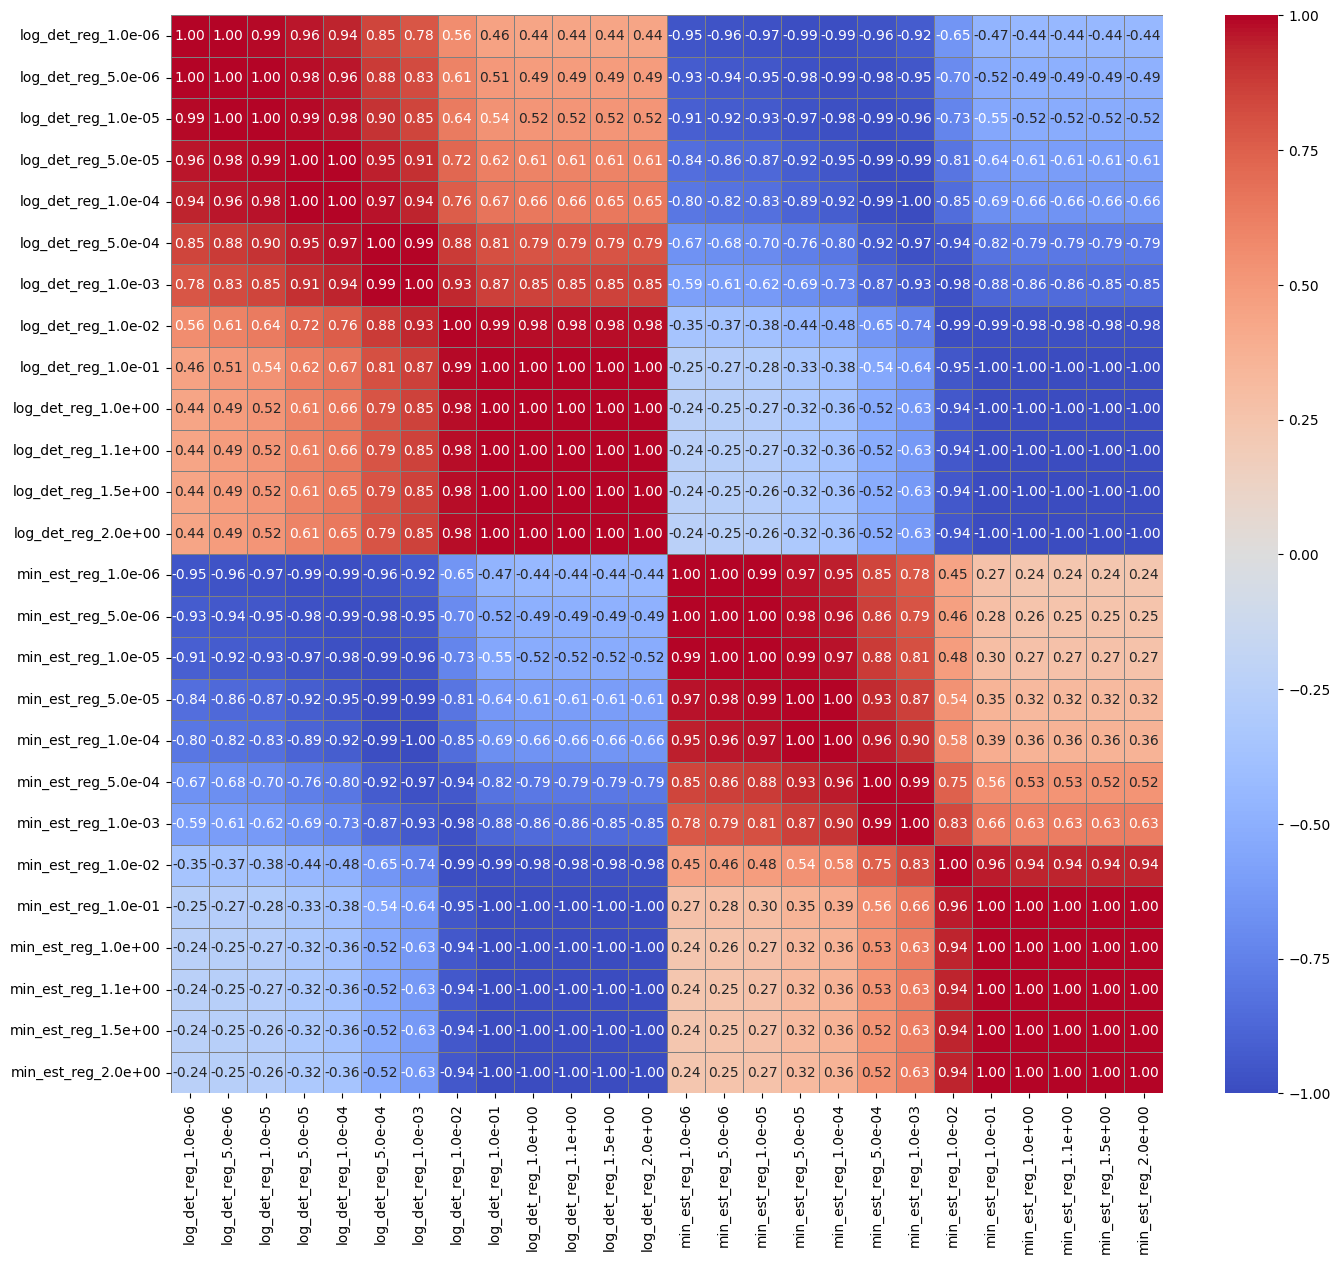

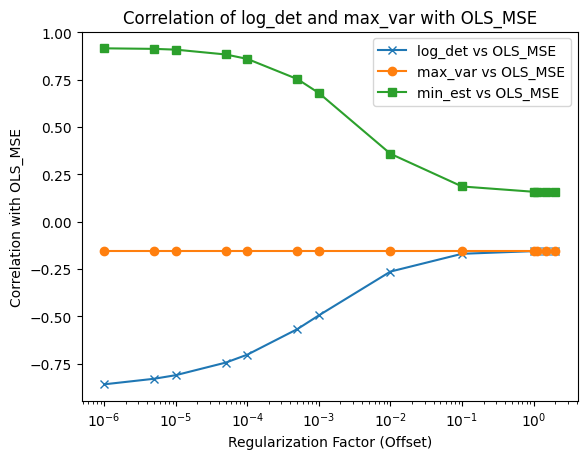

In [27]:
log_min_corr(D_MDTB)
metric_ols_corr(D_MDTB)
